<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/42_gradient_boosting_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    rf_acc
)

Random Forest Accuracy: 0.92


In [5]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

gb_pred = gb.predict(
    X_test
)

gb_acc = accuracy_score(
    y_test,
    gb_pred
)

print(
    "Gradient Boosting Accuracy:",
    gb_acc
)

Gradient Boosting Accuracy: 0.92


In [6]:
comparison = pd.DataFrame({
    "Model":[
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        rf_acc,
        gb_acc
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.92
1,Gradient Boosting,0.92


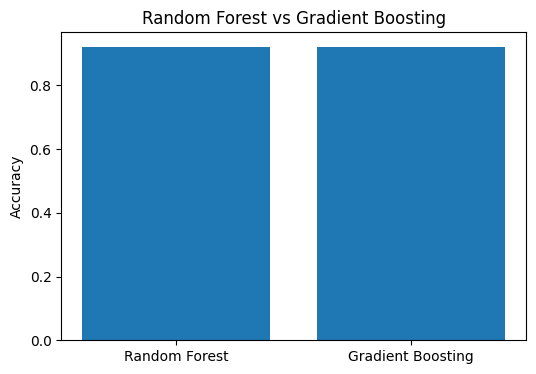

In [7]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title(
    "Random Forest vs Gradient Boosting"
)

plt.show()

In [8]:
results = []

for n in [10, 50, 100, 200]:

    model = GradientBoostingClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    results.append(
        [n, acc]
    )

In [9]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Estimators",
        "Accuracy"
    ]
)

results_df

,Estimators,Accuracy
0,10,0.88
1,50,0.93
2,100,0.92
3,200,0.89


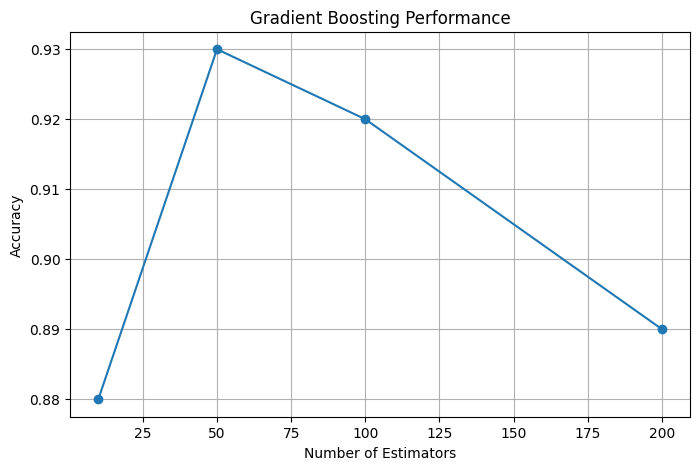

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Estimators"],
    results_df["Accuracy"],
    marker='o'
)

plt.xlabel("Number of Estimators")

plt.ylabel("Accuracy")

plt.title(
    "Gradient Boosting Performance"
)

plt.grid()

plt.show()

## Conclusion

Gradient Boosting improves predictions by sequentially correcting previous errors.

Observations:
- Models are built one after another.
- Each model focuses on reducing remaining mistakes.
- Gradient Boosting often achieves strong predictive performance.
- It forms the basis of modern boosting algorithms such as XGBoost and LightGBM.